# tugas-1-unsupervised-learning

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan FIFA 24 player stats Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/rehandl23/fifa-24-player-stats-dataset

Tujuan utama dari tugas ini adalah membangun model K-means, HC, DBSCAN. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal
- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model K-MEAN
- Bangun model K-MEAN dengan K masing-masing (3,5,7)
- lakukan pengaturan hyperparameter pada K-MEAN
- Lakukan Elbow Method untuk mendapatkan nilai K paling optimal
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


4. Eksperimen Model HC
- Bangun model HC agglomerative dengan n_cluster (3,5,7, dan K hasil elbow Method K-MEAN sebelumnya)
- coba semua linkedage (`'ward', 'complete', 'average', 'single'`)
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Eksperimen Model DBSCAN
- Bangun model DBSCAN
- Lakukan eksperiment dengan mengubah hyperparameter `metric=`
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.

# 1. Persiapan Dataset & Eksplorasi Awal

## Import Library

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# 2. Preprocessing




## Baca dataset

In [78]:
df = pd.read_csv('player_stats.csv', encoding='latin1')
display(df.head())

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


## Gunakan kolom Dengan Tipe Data Numerik Saja

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [80]:
df = df.drop('marking', axis=1)

In [81]:
non_int_col = df.select_dtypes(include='object')
display(non_int_col.head())

,player,country,club,value
0,Cristian Castro Devenish,Colombia,Atl. Nacional,$1.400.000
1,Silaldo Taffarel,Brazil,Corinthians,$975.00
2,Thomas DÃ¤hne,Germany,Holstein Kiel,$1.100.000
3,Michael Sollbauer,Austria,SK Rapid Wien,$650.00
4,Diego Segovia,Uruguay,Independiente,$300.00


In [82]:
df = df.drop(['player', 'country', 'club'], axis=1)
df['value'] = df['value'].astype(str).str.replace(r'[$ .]', '', regex=True).astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   height          5682 non-null   int64  
 1   weight          5682 non-null   int64  
 2   age             5682 non-null   int64  
 3   ball_control    5682 non-null   int64  
 4   dribbling       5682 non-null   int64  
 5   slide_tackle    5682 non-null   int64  
 6   stand_tackle    5682 non-null   int64  
 7   aggression      5682 non-null   int64  
 8   reactions       5682 non-null   int64  
 9   att_position    5682 non-null   int64  
 10  interceptions   5682 non-null   int64  
 11  vision          5682 non-null   int64  
 12  composure       5682 non-null   int64  
 13  crossing        5682 non-null   int64  
 14  short_pass      5682 non-null   int64  
 15  long_pass       5682 non-null   int64  
 16  acceleration    5682 non-null   int64  
 17  stamina         5682 non-null   i

## Cek Apabila Terdapat Data yang Terduplikat

In [83]:
print(f"Jumlah baris sebelum menghapus duplikat: {df.shape[0]}")

print("Duplicate row:")
duplicate = df[df.duplicated(keep=False)]
display(duplicate)

df_clean = df.drop_duplicates()
print(f"Jumlah baris setelah menghapus duplikat: {df_clean.shape[0]}")

Jumlah baris sebelum menghapus duplikat: 5682
Duplicate row:


,height,weight,age,ball_control,dribbling,slide_tackle,stand_tackle,aggression,reactions,att_position,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
154,180,88,29,45,19,17,17,34,78,7,...,16,14,23,19,70,72,70,70,75,2200000.0
156,190,84,32,55,45,64,70,69,54,38,...,33,31,42,40,14,13,7,10,12,70000.0
157,181,78,24,55,53,57,60,61,58,45,...,34,25,32,28,8,13,9,7,8,35000.0
158,180,88,29,45,19,17,17,34,78,7,...,16,14,23,19,70,72,70,70,75,2200000.0
159,190,84,32,55,45,64,70,69,54,38,...,33,31,42,40,14,13,7,10,12,70000.0
160,181,78,24,55,53,57,60,61,58,45,...,34,25,32,28,8,13,9,7,8,35000.0
916,174,69,31,86,88,38,42,75,91,90,...,77,64,75,75,7,10,10,15,14,101000000.0
5229,182,73,24,91,93,32,34,64,93,92,...,80,69,84,83,11,13,5,7,6,153500000.0
5675,182,73,24,91,93,32,34,64,93,92,...,80,69,84,83,11,13,5,7,6,153500000.0
5678,174,69,31,86,88,38,42,75,91,90,...,77,64,75,75,7,10,10,15,14,101000000.0


Jumlah baris setelah menghapus duplikat: 5677


## Deteksi Data Outlier Menggunakan Box Plot

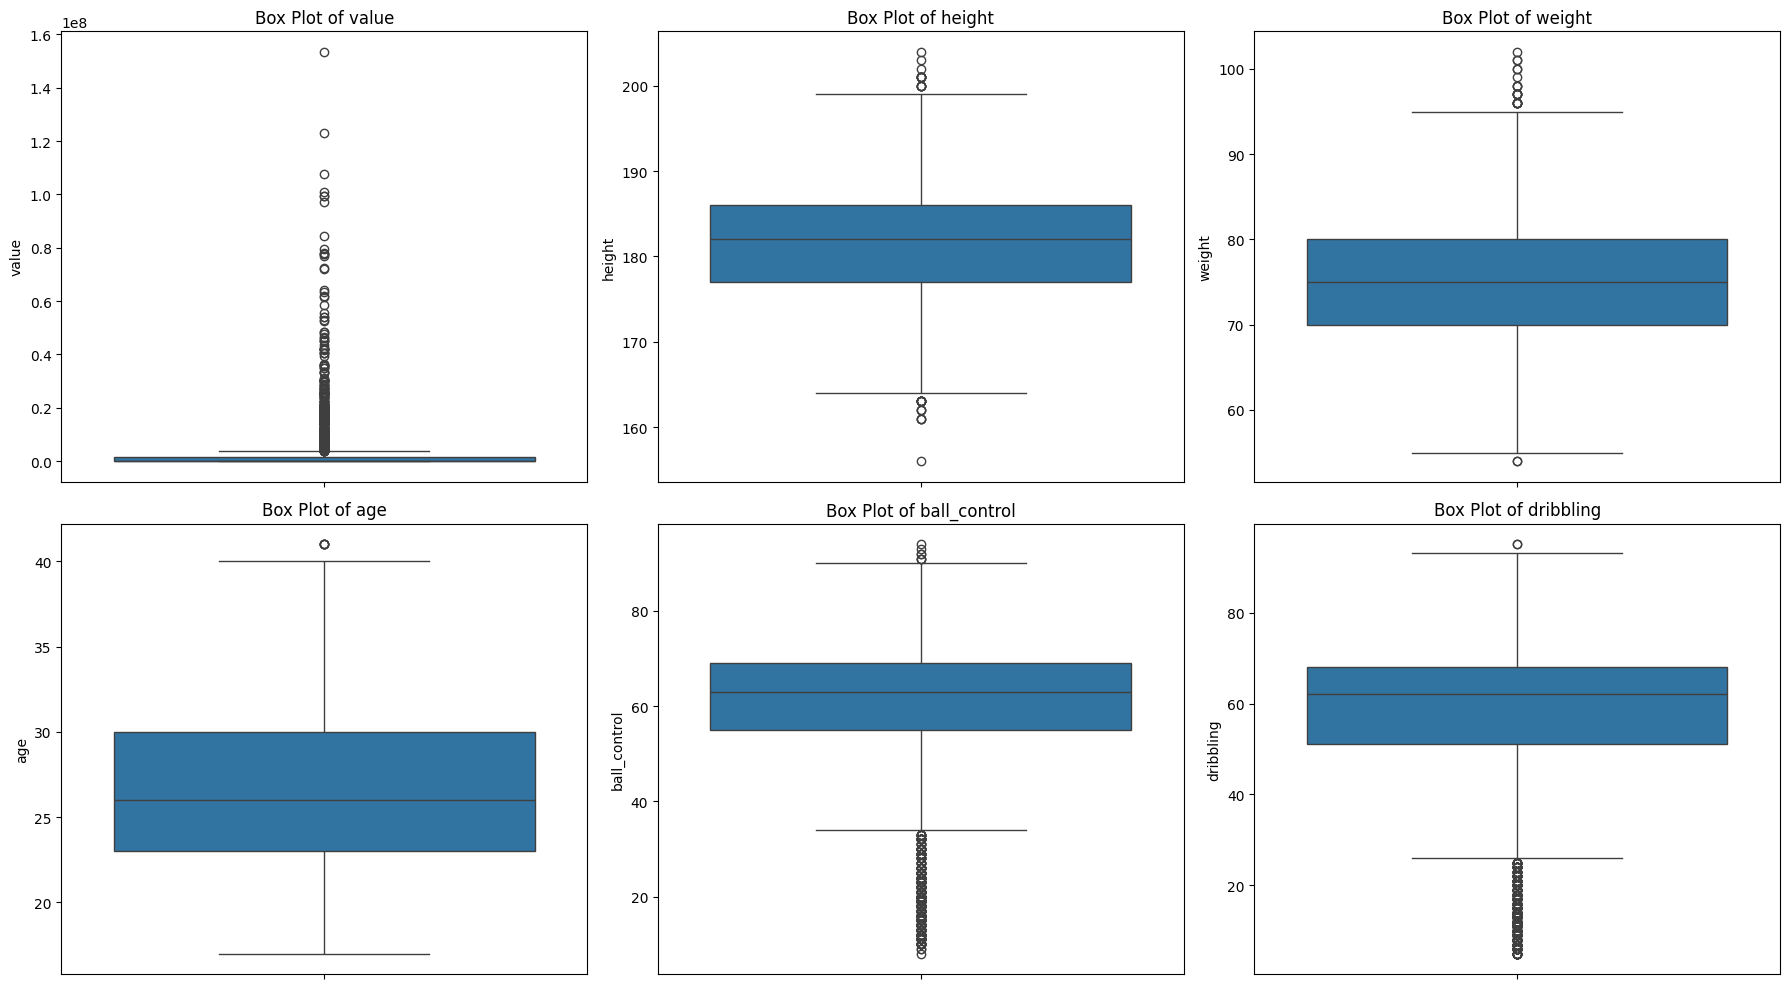

In [84]:
outlier_columns = ['value', 'height', 'weight', 'age', 'ball_control', 'dribbling']

plt.figure(figsize=(18, 10))
for i, col in enumerate(outlier_columns):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    
plt.tight_layout()
plt.show()

## Heatmap Hubungan Antar Kolom

<Axes: >

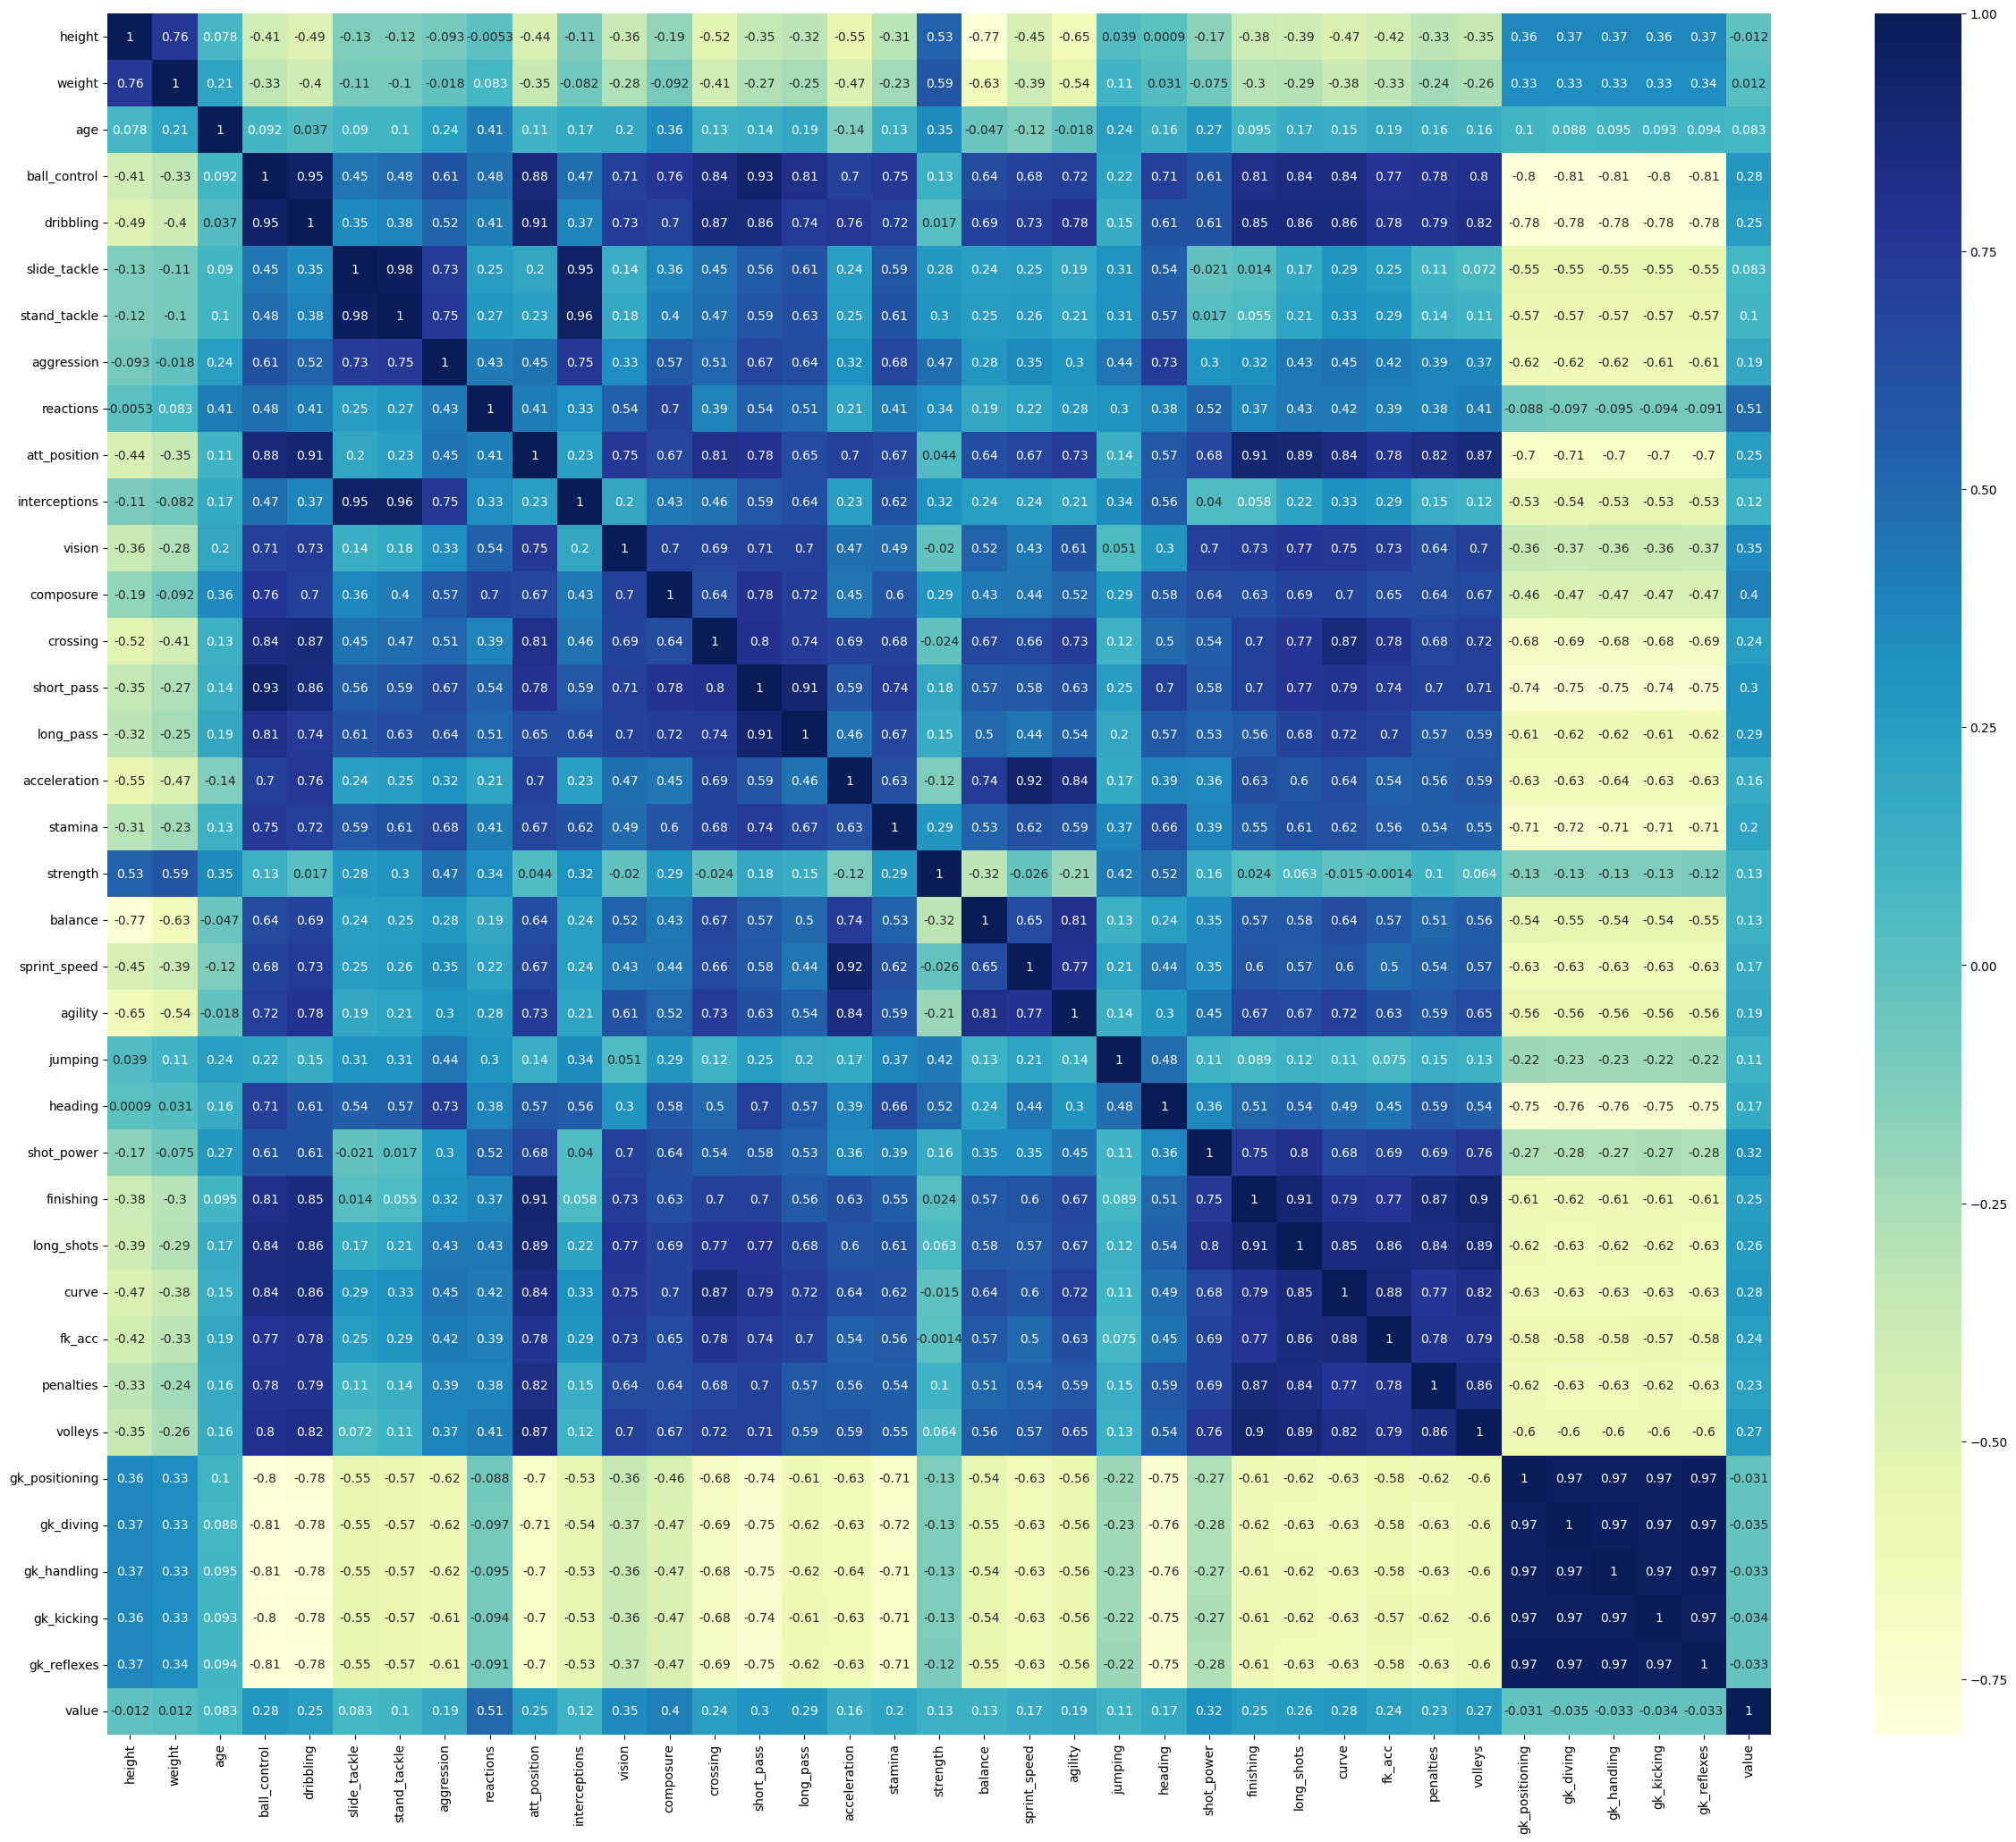

In [85]:
plt.figure(figsize=(30, 25))
sns.heatmap(df_clean.corr(), cmap="YlGnBu", annot=True)

## Reduksi Menggunakan PCA

In [86]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_clean)
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
print("PCA explained variance ratio:\n", " ".join(map("{:.3f}".format, pca.explained_variance_ratio_)))

PCA explained variance ratio:
 1.000 0.000


## Gunakan Scaler Untuk Handle Outlier Ekstrem

In [87]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)
df_scaled = pd.DataFrame(df_scaled, columns=df_pca.columns)

display(df_scaled.head())

,PC1,PC2
0,-0.114478,-0.293448
1,-0.294586,0.681850
2,-0.155961,-2.428438
3,-0.299080,-0.239902
4,-0.303919,-2.759949


# 3. Eksperimen Model K-MEANS


## Fit model untuk n_cluster = 3, 5, dan 7

In [88]:
df_kmeans = df_scaled.copy()

In [89]:
wcss = []
scores = []
for i in range(2, 12):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_kmeans)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_kmeans, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [6539.711084304519]
silhoutte score for n_clusters = 2 is 0.7600233494217852
wcss score for n_cluster = 3 is [6539.711084304519, 3185.01154240472]
silhoutte score for n_clusters = 3 is 0.778372805154546
wcss score for n_cluster = 4 is [6539.711084304519, 3185.01154240472, 1925.7464866794735]
silhoutte score for n_clusters = 4 is 0.778402973569607
wcss score for n_cluster = 5 is [6539.711084304519, 3185.01154240472, 1925.7464866794735, 1355.5078603088832]
silhoutte score for n_clusters = 5 is 0.5114956985324572
wcss score for n_cluster = 6 is [6539.711084304519, 3185.01154240472, 1925.7464866794735, 1355.5078603088832, 998.1765655943228]
silhoutte score for n_clusters = 6 is 0.5220696873009804
wcss score for n_cluster = 7 is [6539.711084304519, 3185.01154240472, 1925.7464866794735, 1355.5078603088832, 998.1765655943228, 825.7662443399923]
silhoutte score for n_clusters = 7 is 0.5265997115543933
wcss score for n_cluster = 8 is [6539.711084304519, 3185.0115

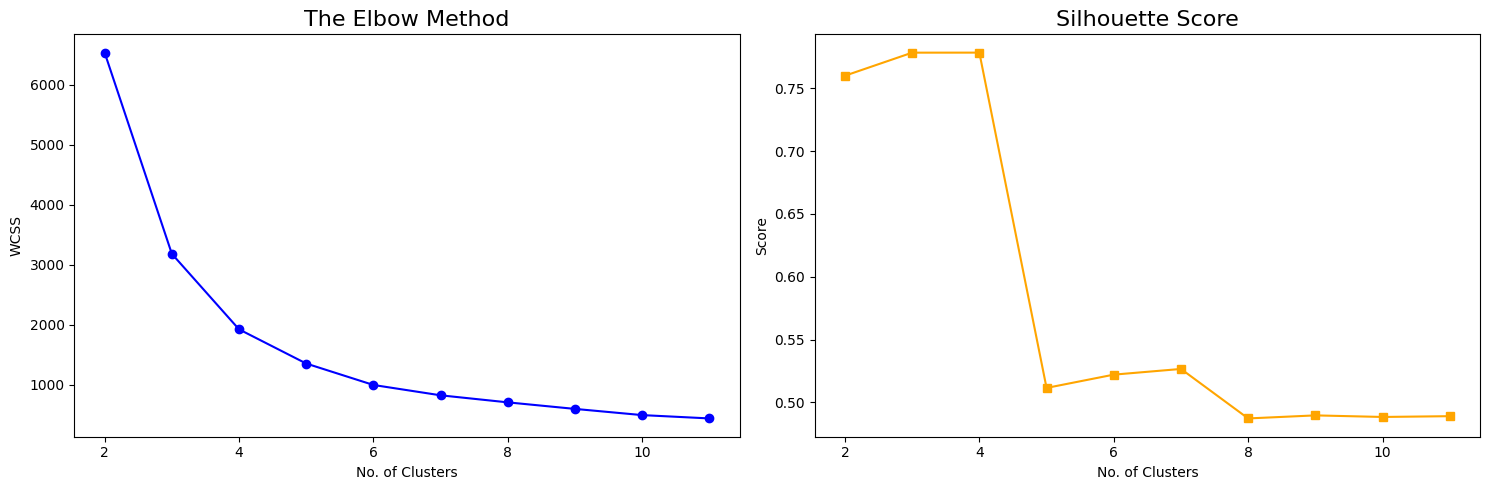

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Grafik 1: WCSS (Elbow Method)
axes[0].plot(range(2, 12), wcss, marker='o', color='blue')
axes[0].set_title('The Elbow Method', fontsize=16)
axes[0].set_xlabel('No. of Clusters')
axes[0].set_ylabel('WCSS')
# Grafik 2: Silhouette Score
axes[1].plot(range(2, 12), scores, marker='s', color='orange')
axes[1].set_title('Silhouette Score', fontsize=16)
axes[1].set_xlabel('No. of Clusters')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

In [91]:
k = 3
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k3 = kmeans.fit_predict(df_kmeans)

k = 4
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k4 = kmeans.fit_predict(df_kmeans)

k = 5
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k5 = kmeans.fit_predict(df_kmeans)

k = 7
kmeans = KMeans(n_clusters=k, init ='k-means++', random_state=42, n_init=10)
clusters_k7 = kmeans.fit_predict(df_kmeans)

In [92]:
df_kmeans['cluster_k3'] = clusters_k3
df_kmeans['cluster_k4'] = clusters_k4
df_kmeans['cluster_k5'] = clusters_k5
df_kmeans['cluster_k7'] = clusters_k7

print(f"Data setelah penambahan label klaster K-Means (cluster ditambahkan ke df_kmeans untuk visualisasi):")
display(df_kmeans.head())

Data setelah penambahan label klaster K-Means (cluster ditambahkan ke df_kmeans untuk visualisasi):


,PC1,PC2,cluster_k3,cluster_k4,cluster_k5,cluster_k7
0,-0.114478,-0.293448,0,1,0,1
1,-0.294586,0.681850,0,1,4,5
2,-0.155961,-2.428438,1,3,2,3
3,-0.299080,-0.239902,0,1,0,1
4,-0.303919,-2.759949,1,3,2,3


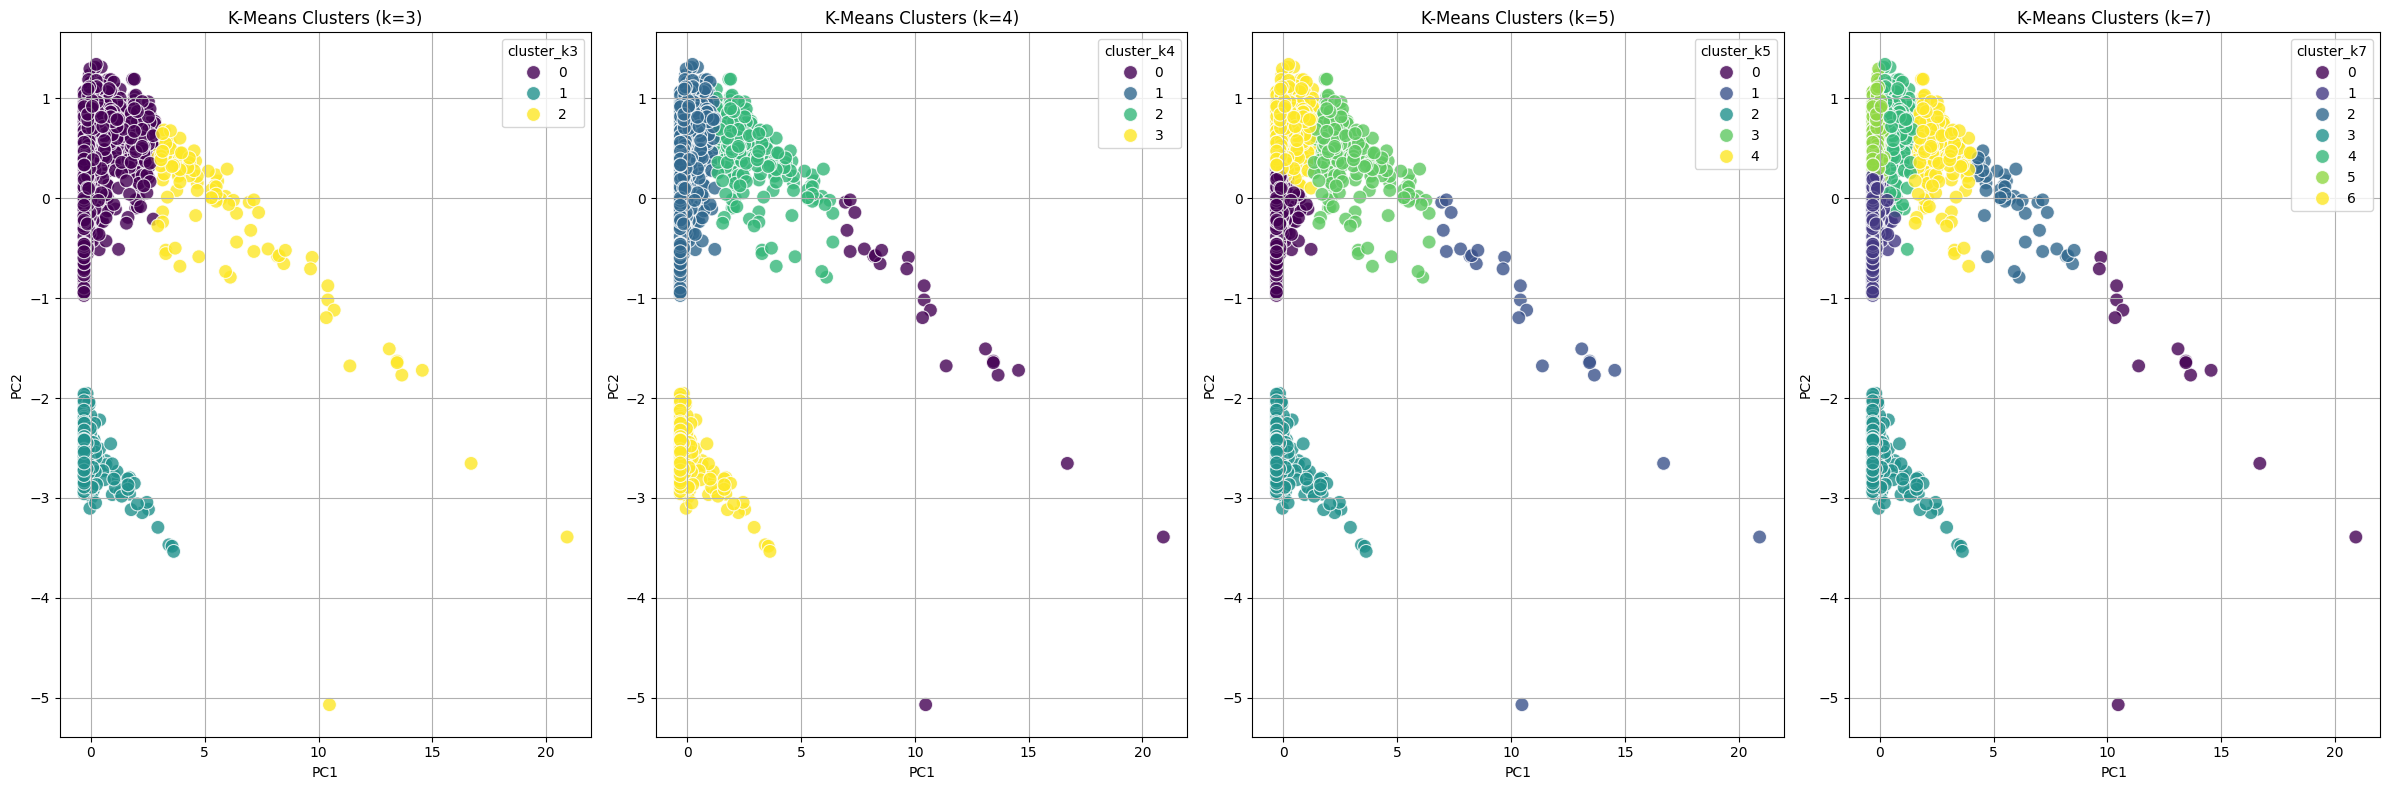

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k3', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('K-Means Clusters (k=3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True)

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k4', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('K-Means Clusters (k=4)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True)

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k5', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[2])
axes[2].set_title('K-Means Clusters (k=5)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True)

sns.scatterplot(x='PC1', y='PC2', hue='cluster_k7', data=df_kmeans, palette='viridis', s=100, alpha=0.8, ax=axes[3])
axes[3].set_title('K-Means Clusters (k=7)')
axes[3].set_xlabel('PC1')
axes[3].set_ylabel('PC2')
axes[3].grid(True)

plt.tight_layout()
plt.show()

# 4. Eksperimen Model HC


In [94]:
df_hc = df_scaled.copy()

In [95]:
linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]
for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 12):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j]) # Menggunakan Ward Method
        AC.fit(df_hc)
        
        labels = AC.labels_
        silhouette_avg = silhouette_score(df_hc, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.7448377957567743
silhoutte score for n_clusters = 3 is 0.7841936293420488
silhoutte score for n_clusters = 4 is 0.7843674336979762
silhoutte score for n_clusters = 5 is 0.5037099683665056
silhoutte score for n_clusters = 6 is 0.5066813567415515
silhoutte score for n_clusters = 7 is 0.5207293264396174
silhoutte score for n_clusters = 8 is 0.5200397130241792
silhoutte score for n_clusters = 9 is 0.4775605666393972
silhoutte score for n_clusters = 10 is 0.4787896568754801
silhoutte score for n_clusters = 11 is 0.4787991711781653

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.8997641647600547
silhoutte score for n_clusters = 3 is 0.8943136491627399
silhoutte score for n_clusters = 4 is 0.811543305238778
silhoutte score for n_clusters = 5 is 0.8114896342839005
silhoutte score for n_clusters = 6 is 0.7653993566112817
silhoutte score for n_clusters = 7 is 0.7719074680270445
silhoutte score for n_cl

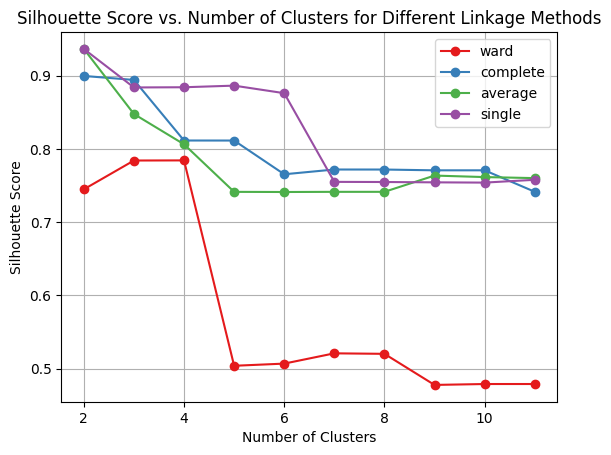

In [96]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 12), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

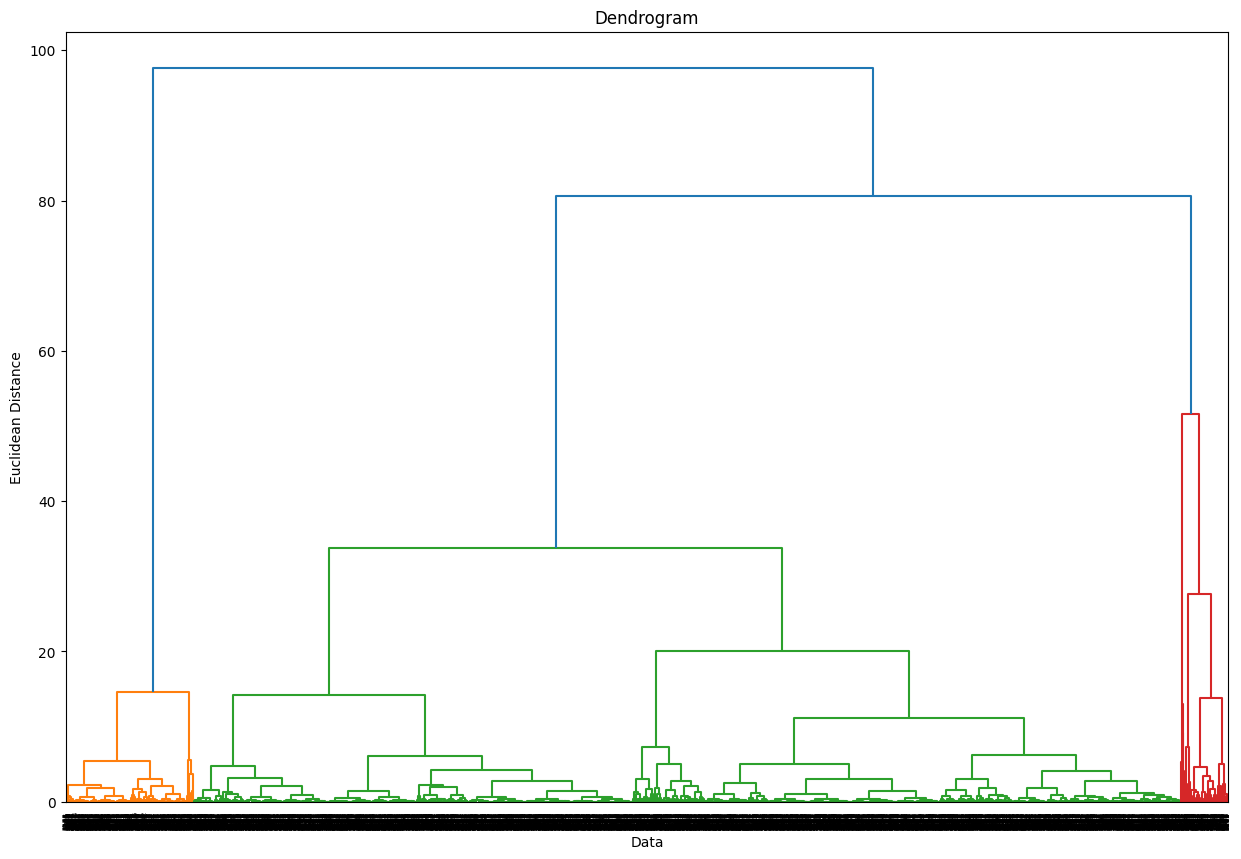

In [97]:
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(sch.linkage(df_hc, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data")
plt.ylabel("Euclidean Distance")
plt.show()

In [105]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_cluster = hc.fit_predict(df_hc)

df_hc['hc_cluster'] = hc_cluster

df_hc.head()

,PC1,PC2,hc_cluster
0,-0.114478,-0.293448,0
1,-0.294586,0.681850,0
2,-0.155961,-2.428438,2
3,-0.299080,-0.239902,0
4,-0.303919,-2.759949,2


<Axes: xlabel='PC1', ylabel='PC2'>

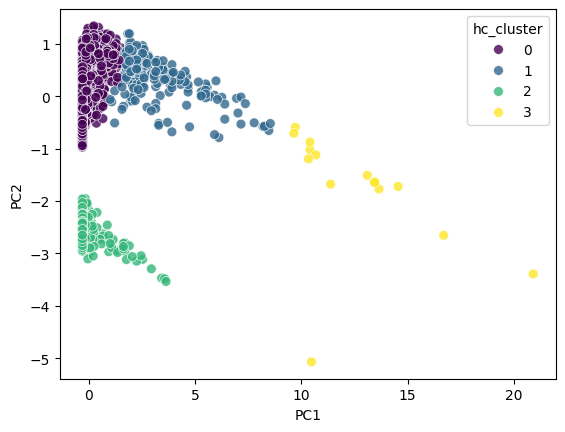

In [106]:
sns.scatterplot(x='PC1', y='PC2', hue='hc_cluster', data=df_hc, palette='viridis', s=50, alpha=0.8)

# 5. Eksperimen Model DBSCAN


In [107]:
df_dbscan = df_scaled.copy()

In [108]:
epsilon = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples = [10, 15, 20, 25]

sil_avg = []
max_value = (0, 0, 0, -1)  # Initialize max_value with a negative silhouette score

for i in range(len(epsilon)):
    for j in range(len(min_samples)):
        db = DBSCAN(min_samples=min_samples[j], eps=epsilon[i]).fit(df_dbscan)

        # Check if there are at least two clusters
        unique_labels = set(db.labels_)
        if len(unique_labels) >= 2:
            core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
            core_samples_mask[db.core_sample_indices_] = True
            labels = db.labels_

            # Number of clusters in labels, ignoring noise if present.
            n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
            n_noise_ = list(labels).count(-1)

            silhouette_avg = silhouette_score(df_dbscan, labels)
            sil_avg.append(silhouette_avg)

            if silhouette_avg > max_value[3]:
                max_value = (epsilon[i], min_samples[j], n_clusters_, silhouette_avg)

print("epsilon =", max_value[0],
      "\nmin_samples =", max_value[1],
      "\nnumber of clusters =", max_value[2],
      "\naverage silhouette score = %.4f" % max_value[3])

epsilon = 1.0 
min_samples = 10 
number of clusters = 1 
average silhouette score = 0.8919


--- Memulai Evaluasi DBSCAN (min_samples = 10) ---

✅ Selesai! Epsilon Paling Optimal adalah: 1.0
🏆 Dengan Silhouette Score: 0.8919


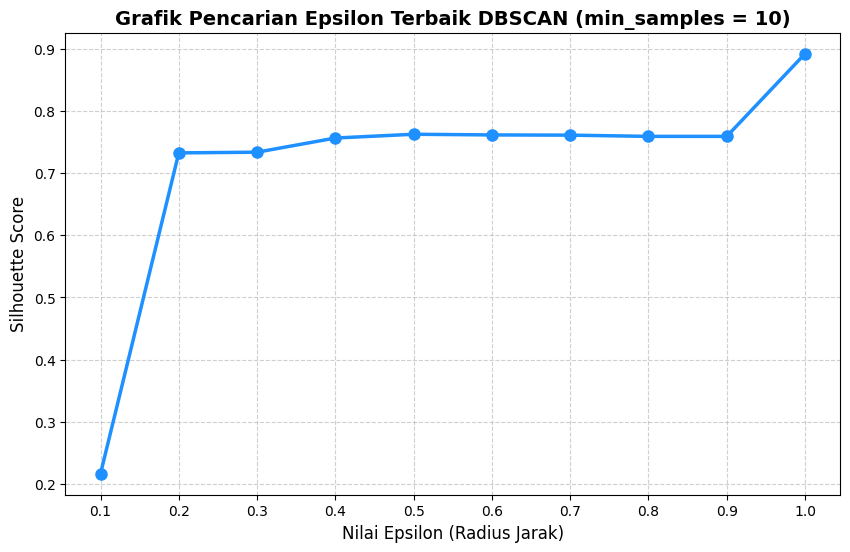

In [109]:
import matplotlib.pyplot as plt

# Parameter Anda
epsilon = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_fixed = 10

# Siapkan list kosong untuk sumbu X (Epsilon valid) dan Sumbu Y (Skor)
eps_valid = []
sil_scores = []
max_value = (0, -1)  # (best_epsilon, best_score)

print(f"--- Memulai Evaluasi DBSCAN (min_samples = {min_samples_fixed}) ---")

for eps in epsilon:
    # Jalankan DBSCAN
    db = DBSCAN(min_samples=min_samples_fixed, eps=eps).fit(df_dbscan)
    unique_labels = set(db.labels_)
    
    # Hanya hitung Silhouette jika minimal ada 2 grup (termasuk grup 'Noise')
    if len(unique_labels) >= 2:
        labels = db.labels_
        silhouette_avg = silhouette_score(df_dbscan, labels)
        
        # Simpan koordinat X dan Y untuk grafik
        eps_valid.append(eps)
        sil_scores.append(silhouette_avg)
        
        # Catat juara tertingginya
        if silhouette_avg > max_value[1]:
            max_value = (eps, silhouette_avg)

# --- BAGIAN REPORT TEXT ---
if len(eps_valid) > 0:
    print(f"\n✅ Selesai! Epsilon Paling Optimal adalah: {max_value[0]}")
    print(f"🏆 Dengan Silhouette Score: {max_value[1]:.4f}")
else:
    print("\n⚠️ PERINGATAN: Tidak ada Epsilon yang berhasil membentuk >= 2 kluster.")

# --- BAGIAN VISUALISASI GRAFIK ---
plt.figure(figsize=(10, 6))

# Gambar garis line plot (dengan penanda titik bulat 'o')
plt.plot(eps_valid, sil_scores, marker='o', linestyle='-', color='dodgerblue', linewidth=2.5, markersize=8)

# Percantik Grafik
plt.title(f'Grafik Pencarian Epsilon Terbaik DBSCAN (min_samples = {min_samples_fixed})', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Epsilon (Radius Jarak)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(epsilon) # Paksa sumbu X menampilkan angka epsilon yang dicek persis
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [122]:
db=DBSCAN(eps=0.4, min_samples=20, metric='euclidean')

db_cluster = db.fit_predict(df_dbscan)

df_dbscan['cluster'] = db_cluster
df_dbscan.head()

,PC1,PC2,cluster
0,-0.114478,-0.293448,0
1,-0.294586,0.681850,0
2,-0.155961,-2.428438,1
3,-0.299080,-0.239902,0
4,-0.303919,-2.759949,1


<Axes: xlabel='PC1', ylabel='PC2'>

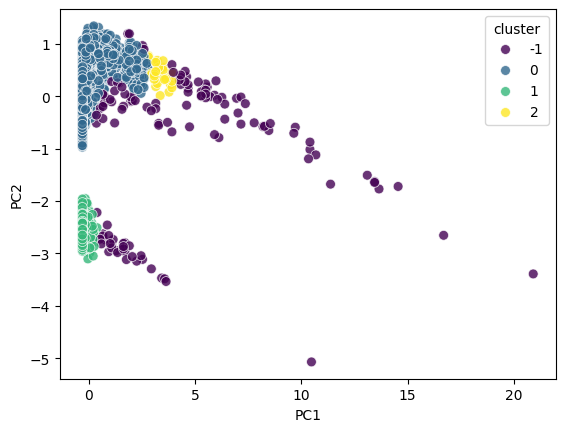

In [123]:
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_dbscan, palette='viridis', s=50, alpha=0.8)

# 6. Analisis & Kesimpulan